In [1]:
import os
import re
import zipfile
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    ConfusionMatrixDisplay, precision_recall_curve
)
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")
np.random.seed(42)

In [3]:
DATA_URL = "https://archive.ics.uci.edu/static/public/228/sms%2Bspam%2Bcollection.zip"
ZIP_PATH = "sms_spam_collection.zip"
EXTRACT_DIR = "sms_spam_data"
DATA_FILE = os.path.join(EXTRACT_DIR, "SMSSpamCollection")
print(DATA_FILE)

sms_spam_data/SMSSpamCollection


In [4]:
if not os.path.exists(DATA_FILE): # checks if the path exist for the first run it does not
    print("Downloading the UCI SMS Spam Collection...")
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH) # this line opens the link , downloads the dataset and saves as the zip_path
    with zipfile.ZipFile(ZIP_PATH, "r") as z: # open the zip file in read mode
        z.extractall(EXTRACT_DIR) # as the file is opened in read mode extract it and save it in the extract_dir folder

In [5]:
print(DATA_FILE)

sms_spam_data/SMSSpamCollection


In [6]:
df = pd.read_csv(
    DATA_FILE,
    sep="\t", # seprator the data is seprated by tab
    names=["label", "text"], #this is the names of the columns in the datatset
    encoding="utf-8" # encoding
)

In [7]:
print("Dataset shape:", df.shape) ## printing the shape
print(df.head()) # prints the first 5 rows

# ============================================================
# 2. BASIC PANDAS INSPECTION
# ============================================================
print("\nINFO -----------------------------------")
print(df.info())

print("\n--- MISSING VALUES ---")
print(df.isna().sum())

print("\n--- DUPLICATES ---")
print(df.duplicated().sum())

print("\n--- CLASS COUNTS ---")
print(df["label"].value_counts(normalize=False))

print("\n--- CLASS PERCENTAGES ---")
print((df["label"].value_counts(normalize=True) * 100).round(2))

Dataset shape: (5572, 2)
  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

INFO -----------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

--- MISSING VALUES ---
label    0
text     0
dtype: int64

--- DUPLICATES ---
403

--- CLASS COUNTS ---
label
ham     4825
spam     747
Name: count, dtype: int64

--- CLASS PERCENTAGES ---
label
ham     86.59
spam    13.41
Name: proportion, dtype: float64


In [8]:
df = df.drop_duplicates().reset_index(drop=True)
df["target"] = df["label"].map({"ham": 0, "spam": 1})

In [9]:
# ============================================================
# 3. PYTHON STRING LOGIC + FEATURE ENGINEERING
# ============================================================
def count_digits(text):
    return sum(ch.isdigit() for ch in text)


def count_uppercase(text):
    return sum(ch.isupper() for ch in text)


def count_exclamations(text):
    return text.count("!")


def count_currency_symbols(text):
    return sum(ch in "£$€₹" for ch in text)


def contains_url(text):
    return int(bool(re.search(r"https?://|www\.", text.lower())))


df["char_count"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()
df["digit_count"] = df["text"].apply(count_digits)
df["uppercase_count"] = df["text"].apply(count_uppercase)
df["exclamation_count"] = df["text"].apply(count_exclamations)
df["currency_count"] = df["text"].apply(count_currency_symbols)
df["has_url"] = df["text"].apply(contains_url)

In [10]:
df.head()

,label,text,target,char_count,word_count,digit_count,uppercase_count,exclamation_count,currency_count,has_url
0,ham,"Go until jurong point, crazy.. Available only ...",0,111,20,0,3,0,0,0
1,ham,Ok lar... Joking wif u oni...,0,29,6,0,2,0,0,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,28,25,10,0,0,0
3,ham,U dun say so early hor... U c already then say...,0,49,11,0,2,0,0,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61,13,0,2,0,0,0


In [ ]:
#rough work

In [11]:
s = "versha versha hfdopsfqe hfauofqurqfgw"
len(s.split())

4

In [12]:
s = "versha versha"
len(s)

13

In [14]:
def count_digits(text):
    return sum(ch.isdigit() for ch in text)
count_digits("traeturgafaef56789  9090sfgS ")

9

In [15]:
def count_uppercase(text):
    return sum(ch.isupper() for ch in text)

count_uppercase("usetejtebtsestuoehtAAAA  SSGSRGRS")

12

In [16]:
def count_exclamations(text):
    return text.count("!")

count_exclamations("uyiuyu!!!")

3

In [17]:
def count_currency_symbols(text):
    return sum(ch in "£$€₹" for ch in text)
count_currency_symbols("sdjgis£₹lgs  ₹")

3

In [18]:
def contains_url(text):
    return int(bool(re.search(r"https?://|www\.", text.lower())))

contains_url("https://www")


1

In [19]:
# ============================================================
# 4. REGEX-BASED NLP CLEANING
# ============================================================
def clean_sms(text):
    text = str(text).lower()

    # Preserve important concepts as tokens rather than deleting them.
    text = re.sub(r"https?://\S+|www\.\S+", " urltoken ", text) #wherever in ur data u find a text similar to url replace the link with the word "urltoken"
    text = re.sub(r"[£$€₹]+", " moneytoken ", text) #whenevr in ur data u find a text which has any of these sybmols  replace them with the word "moneytoken"
    text = re.sub(r"\b\d+(?:[.,]\d+)?\b", " numbertoken ", text) # wherver in ur data numbers r been taked about replace them with "numbertoken"

    # Remove remaining non-alphabetic characters.
    text = re.sub(r"[^a-z\s]", " ", text) # any other thing other than alphabets or space remove it

    # Collapse repeated whitespace.
    text = re.sub(r"\s+", " ", text).strip() # any extra space remove it
    return text


df["clean_text"] = df["text"].apply(clean_sms)

In [20]:
df.head()

,label,text,target,char_count,word_count,digit_count,uppercase_count,exclamation_count,currency_count,has_url,clean_text
0,ham,"Go until jurong point, crazy.. Available only ...",0,111,20,0,3,0,0,0,go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,0,29,6,0,2,0,0,0,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,28,25,10,0,0,0,free entry in numbertoken a wkly comp to win f...
3,ham,U dun say so early hor... U c already then say...,0,49,11,0,2,0,0,0,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61,13,0,2,0,0,0,nah i don t think he goes to usf he lives arou...


In [21]:
pd.set_option("display.max_colwidth", None)

In [22]:
df.head()

,label,text,target,char_count,word_count,digit_count,uppercase_count,exclamation_count,currency_count,has_url,clean_text
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",0,111,20,0,3,0,0,0,go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat
1,ham,Ok lar... Joking wif u oni...,0,29,6,0,2,0,0,0,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,1,155,28,25,10,0,0,0,free entry in numbertoken a wkly comp to win fa cup final tkts st may numbertoken text fa to numbertoken to receive entry question std txt rate t c s apply over s
3,ham,U dun say so early hor... U c already then say...,0,49,11,0,2,0,0,0,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives around here though",0,61,13,0,2,0,0,0,nah i don t think he goes to usf he lives around here though


In [23]:
X = df["clean_text"]
y = df["target"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20, # 20% of spam data will be used for testing 80% for training similarly 20% of not spam for testing and 80% training
    random_state=42,
    stratify=y
)

In [25]:
print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain class ratio:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest class ratio:")
print(y_test.value_counts(normalize=True).round(3))


Train shape: (4135,)
Test shape: (1034,)

Train class ratio:
target
0    0.874
1    0.126
Name: proportion, dtype: float64

Test class ratio:
target
0    0.873
1    0.127
Name: proportion, dtype: float64


In [26]:
bow_demo = CountVectorizer(max_features=20, ngram_range=(1, 1)) #keeps atmost 20 unique words ngrams 1,1, ensure u look at each word individually
demo_matrix = bow_demo.fit_transform(X_train.head(8))

bow_df = pd.DataFrame(
    demo_matrix.toarray(),
    columns=bow_demo.get_feature_names_out()
)

print("\n--- SMALL BAG OF WORDS MATRIX ---")
print(bow_df)


--- SMALL BAG OF WORDS MATRIX ---
   all  already  am  anything  been  best  buffet  come  daaaaa  dinner  eat  \
0    0        0   1         0     0     0       0     0       1       0    0   
1    0        1   0         0     0     0       1     0       0       0    1   
2    0        0   0         0     0     0       0     0       0       0    0   
3    1        0   0         0     0     1       0     0       0       0    0   
4    0        0   1         0     0     0       0     1       0       0    0   
5    0        0   0         0     0     0       0     0       0       0    0   
6    0        0   0         0     1     0       0     0       0       0    0   
7    0        0   0         1     0     0       0     0       0       1    0   

   home  later  no  now  numbertoken  still  to  up  you  
0     1      0   0    0            0      1   0   1    1  
1     0      0   0    1            0      0   0   0    0  
2     0      0   1    0            0      0   1   0    1  
3     0 

In [27]:
lr_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),   # cat, dog, chased  cat,dog   cat,chased  dog,chased
        min_df=2, #only and only consider w ord for calculating tf-idf if it is there in 2 sentences atleast
        max_df=0.98, # ignore the word if it coming for more than 98% documents
        sublinear_tf=True
    )),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        C=2.0,
        random_state=42
    ))
])

lr_pipe.fit(X_train, y_train)
lr_pred = lr_pipe.predict(X_test)
lr_proba = lr_pipe.predict_proba(X_test)[:, 1]

In [28]:
# # I dont want water water water water water water water water water

# # It was disgustig actot was diugusting move was disgusting actress was disugusting   count of word/ total words  1+log(word count) 1 + log(1)
# # class weight =   total samples/(no of class *sample in the class)
# 1000 /(2*900)  1000/1800    1000/(200)
# # Class 0: 900 records
# # Class 1: 100 records

# # #The model will give a higher weight to mistakes made on Class 1 because it has fewer examples.

In [29]:
lr_pred[0], lr_proba[0]
# predict by default provides a threshold of 0.5 any value less that 0.5 will become 0 otherwise 1
#predict_proba gives u the probability as outpit if u want any other treshold other than 0.5 u can use that

(np.int64(0), np.float64(0.05049081759349042))

In [30]:
lr_pred[20], lr_proba[20]

(np.int64(0), np.float64(0.27024336282054057))

In [31]:
lr_proba = lr_pipe.predict_proba(X_test)[:, 1]
lr_proba
# Column 0 → Probability of Class 0
# Column 1 → Probability of Class 1
#: selects every  test record
# 1 only looks at the first index

array([0.05049082, 0.03773176, 0.08103702, ..., 0.98542696, 0.16016667,
       0.08191975])

In [32]:
from xgboost import XGBClassifier

xgb_tfidf = TfidfVectorizer(
    ngram_range=(1, 2), #cat, dog, sat, run
    min_df=2,
    max_df=0.98,
    sublinear_tf=True
)

# Fit vectorizer only on training data: avoids data leakage.
X_train_tfidf = xgb_tfidf.fit_transform(X_train)
X_test_tfidf = xgb_tfidf.transform(X_test)

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / positive_count

xgb_model = XGBClassifier(
    n_estimators=180,
    max_depth=4,
    learning_rate=0.08,
    subsample=0.85, #Each tree is trained using a random 85% of the training rows.
    colsample_bytree=0.80, # Each tree considers a random 80% of the TF-IDF features.
    objective="binary:logistic", # The model produces a probability between 0 and 1 using the logistic function.
    eval_metric="logloss",  # Tells XGBoost to evaluate prediction quality using log loss.
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1  #Allows XGBoost to use all available CPU cores during training.
)

xgb_model.fit(X_train_tfidf, y_train)

xgb_pred = xgb_model.predict(X_test_tfidf)
xgb_proba = xgb_model.predict_proba(X_test_tfidf)[:, 1]

print("\n--- XGBOOST REPORT ---")
print(classification_report(y_test, xgb_pred, target_names=["ham", "spam"]))


--- XGBOOST REPORT ---
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       903
        spam       0.97      0.89      0.93       131

    accuracy                           0.98      1034
   macro avg       0.98      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034



In [33]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input, TextVectorization, Embedding, LSTM, Dense, Dropout,
    BatchNormalization, Activation, Conv1D, GlobalMaxPooling1D
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
print("TensorFlow version:", tf.__version__)

# ============================================================
# 16. CREATE TRAIN / VALIDATION / TEST SPLITS FOR DL
# ============================================================
X_train_dl, X_val_dl, y_train_dl, y_val_dl = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("DL train:", X_train_dl.shape)
print("DL validation:", X_val_dl.shape)
print("DL test:", X_test.shape)

# ============================================================
# 17. TEXTVECTORIZATION
# ============================================================
MAX_TOKENS = 8000
SEQUENCE_LENGTH = 60

vectorizer = TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH
)

# Adapt ONLY on training text.
vectorizer.adapt(np.array(X_train_dl))

print("Vocabulary size used:", len(vectorizer.get_vocabulary()))
print("Sample vocabulary:", vectorizer.get_vocabulary()[:20])

sample = tf.constant([
    "free prize claim now",
    "meeting at office tomorrow"
])
print("\nVectorized sample:")
print(vectorizer(sample))

# ============================================================
# 18. LSTM MODEL WITH REGULARIZATION
# ============================================================
EMBEDDING_DIM = 64

lstm_model = Sequential([
    Input(shape=(), dtype=tf.string, name="raw_text"), #shape () means 1 string per example
    vectorizer,

    Embedding(
        input_dim=MAX_TOKENS,
        output_dim=EMBEDDING_DIM,
        mask_zero=True,
        embeddings_regularizer=l2(1e-5) #This discourages excessively large embedding values and helps control overfitting.
    ),

    LSTM(
        32,
        activation="tanh",
        recurrent_activation="sigmoid",
        dropout=0.20
    ),

    Dense(
        32,
        use_bias=False,
        kernel_regularizer=l2(1e-4)
    ),

    BatchNormalization(),
    Activation("relu"),
    Dropout(0.30),
    Dense(1, activation="sigmoid")
])

lstm_model.summary()

# Binary problem -> sigmoid + binary cross entropy.
# Adam uses gradients calculated during backpropagation.
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = lstm_model.fit(
    np.array(X_train_dl),
    np.array(y_train_dl),
    validation_data=(np.array(X_val_dl), np.array(y_val_dl)),
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

TensorFlow version: 2.20.0
DL train: (3308,)
DL validation: (827,)
DL test: (1034,)
Vocabulary size used: 6032
Sample vocabulary: ['', '[UNK]', np.str_('i'), np.str_('numbertoken'), np.str_('you'), np.str_('to'), np.str_('the'), np.str_('a'), np.str_('u'), np.str_('and'), np.str_('in'), np.str_('is'), np.str_('me'), np.str_('my'), np.str_('for'), np.str_('it'), np.str_('your'), np.str_('that'), np.str_('of'), np.str_('s')]

Vectorized sample:
tf.Tensor(
[[ 54 149 141  26   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [318  33 483 157   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]], shape=(2, 60), dtype=int64)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 60)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 60, 64)         │       512,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 525,601 (2.01 MB)

 Trainable params: 525,537 (2.00 MB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.8180 - auc: 0.9589 - loss: 0.4456 - precision: 0.4052 - recall: 0.9402 - val_accuracy: 0.9782 - val_auc: 0.9968 - val_loss: 0.4626 - val_precision: 0.9674 - val_recall: 0.8558
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9876 - auc: 0.9913 - loss: 0.1495 - precision: 0.9456 - recall: 0.9569 - val_accuracy: 0.9879 - val_auc: 0.9976 - val_loss: 0.2092 - val_precision: 0.9896 - val_recall: 0.9135
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.9952 - auc: 0.9961 - loss: 0.0708 - precision: 0.9879 - recall: 0.9737 - val_accuracy: 0.9891 - val_auc: 0.9969 - val_loss: 0.0876 - val_precision: 0.9798 - val_recall: 0.9327
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.9988 - auc: 0.9996 - loss: 0.0377 - precision: 1.0000 - recall: 0.9904 - val_accuracy: 0.9891 - val_auc: 0.9958 - val_loss: 0.0541 - val_precision: 0.9897 - val_recall: 0.9231
Epoch 5/10
104/104 ━━━━━━━━━

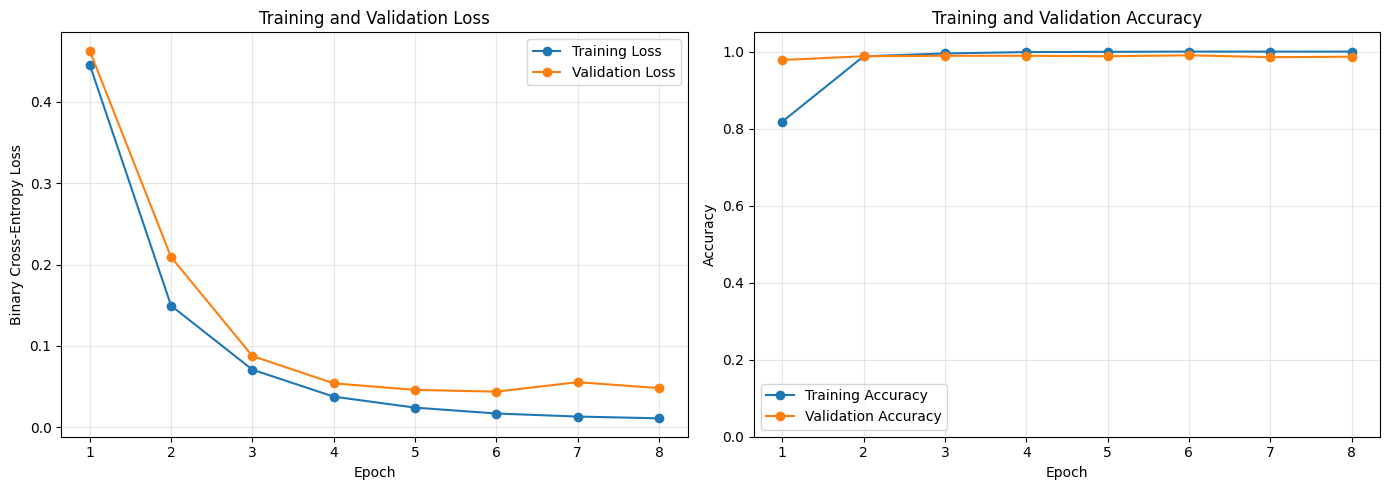

In [34]:
import matplotlib.pyplot as plt

# Values recorded after every epoch
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

train_accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

# Actual number of epochs completed
epochs_run = range(1, len(train_loss) + 1)

plt.figure(figsize=(14, 5))

# ---------------- Loss graph ----------------
plt.subplot(1, 2, 1)

plt.plot(
    epochs_run,
    train_loss,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_run,
    val_loss,
    marker="o",
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.xticks(epochs_run)
plt.grid(alpha=0.3)
plt.legend()

# ---------------- Accuracy graph ----------------
plt.subplot(1, 2, 2)

plt.plot(
    epochs_run,
    train_accuracy,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_run,
    val_accuracy,
    marker="o",
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs_run)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()